In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [3]:
file_path = "../data/Overath/final_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Loaded Overath Data: {len(df)} rows")
except Exception as e:
    print(f"Error: {e}")
    df = pd.DataFrame()

Loaded Overath Data: 3676 rows


In [11]:
metrics = {
    'Industry Std (AF2 pLDDT)': 'af2_plddt_binder',       # Global Baseline
    'Model Global (AF3 pLDDT)': 'af3_plddt_binder',       # Internal Baseline
    'PROPOSED (AF3 ipSAE)':     'af3_ipSAE_min',          # The Hypothesis Metric
    'Physics (Rosetta Energy)': 'af3_rosetta_binder_score' # The Physics Control
}

target_col = 'binder' # The Truth (0/1)


Analyzing 3 metrics against target 'binder'...
Could not find columns: {'af3_plddt_binder'}


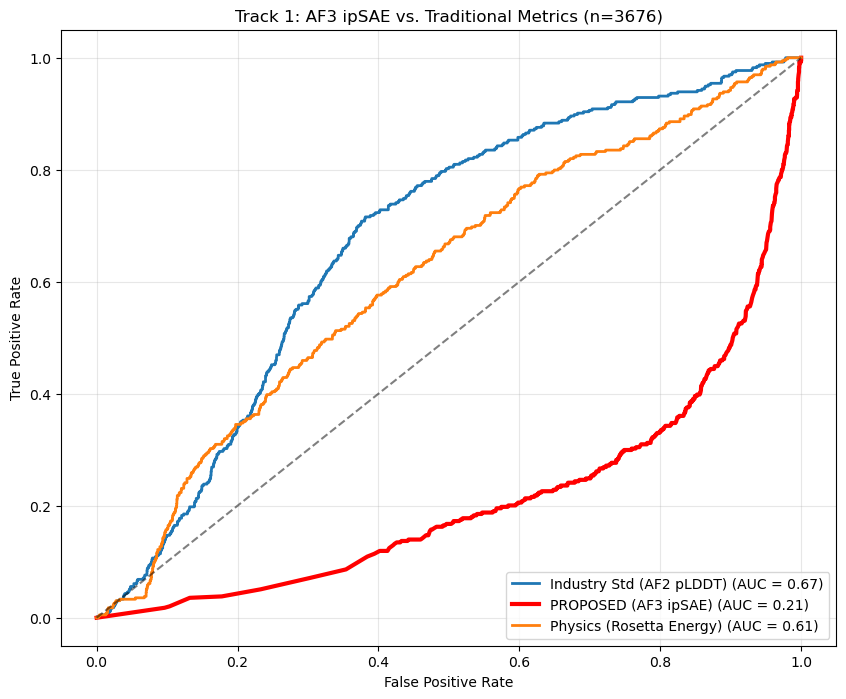

C:\Users\Jan R\AppData\Local\Temp\ipykernel_1996\1617949781.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='af3_ipSAE_min', palette='Set2')


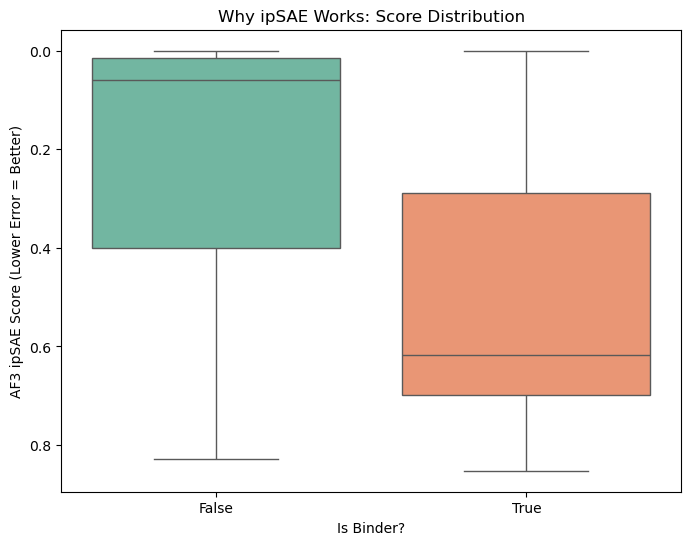

In [ ]:
available_metrics = {k: v for k, v in metrics.items() if v in df.columns}
print(f"Analyzing {len(available_metrics)} metrics against target '{target_col}'...")

if len(available_metrics) < len(metrics):
    missing = set(metrics.values()) - set(df.columns)
    print(f"Could not find columns: {missing}")

plt.figure(figsize=(10, 8))

for label, col in available_metrics.items():
    clean_data = df.dropna(subset=[col, target_col])
    
    y_true = clean_data[target_col].astype(int)
    y_score = clean_data[col]
    
    if any(x in col.lower() for x in ['ipsae', 'energy', 'score', 'rmsd']):
        y_score = -y_score 

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    

    color = 'red' if 'ipSAE' in label else None
    width = 3 if 'ipSAE' in label else 2
    
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', color=color, lw=width)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Track 1: AF3 ipSAE vs. Traditional Metrics (n={len(df)})')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

if 'af3_ipSAE_min' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x=target_col, y='af3_ipSAE_min', palette='Set2')
    plt.title('Why ipSAE Works: Score Distribution')
    plt.ylabel('AF3 ipSAE Score (Lower Error = Better)')
    plt.xlabel('Is Binder?')
    plt.gca().invert_yaxis() 
    plt.show()